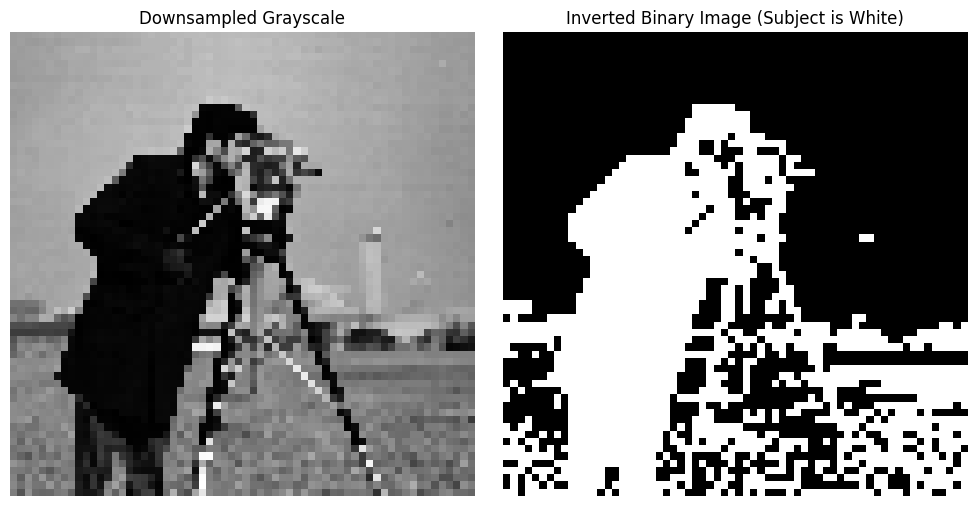

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Read the image in grayscale
img_gray = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE)

if img_gray is None:
    print("Error: Could not read 'cameraman.png'.")
else:
    # 2. Downsample the image
    img_downsampled = img_gray[::4, ::4]
    
    # 3. Convert to a binary image and INVERT
    # By using <= threshold, dark pixels become 1 (white) and light pixels become 0 (black)
    threshold = 127
    img_binary = (img_downsampled <= threshold).astype(np.uint8)

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img_downsampled, cmap='gray')
    axes[0].set_title('Downsampled Grayscale')
    axes[0].axis('off')
    
    axes[1].imshow(img_binary, cmap='gray')
    axes[1].set_title('Inverted Binary Image (Subject is White)')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

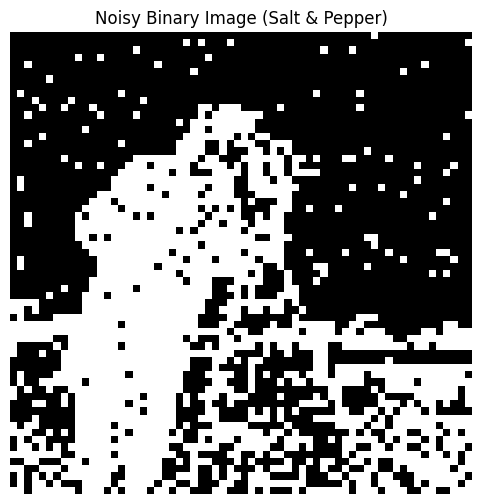

In [10]:
def add_salt_and_pepper_noise(image, salt_prob, pepper_prob):
    noisy = np.copy(image)
    row, col = noisy.shape
    
    # Generate random matrix
    rand_matrix = np.random.rand(row, col)
    
    # Add salt (white pixels)
    noisy[rand_matrix < salt_prob] = 1
    
    # Add pepper (black pixels)
    noisy[rand_matrix > 1 - pepper_prob] = 0
    
    return noisy

# Add 5% salt and 5% pepper noise
img_noisy = add_salt_and_pepper_noise(img_binary, salt_prob=0.05, pepper_prob=0.05)

plt.figure(figsize=(6, 6))
plt.imshow(img_noisy, cmap='gray')
plt.title('Noisy Binary Image (Salt & Pepper)')
plt.axis('off')
plt.show()

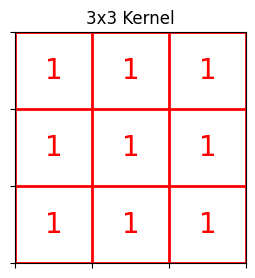

In [11]:
# Create a 3x3 kernel
kernel = np.ones((3, 3), dtype=np.uint8)

# Display the kernel as an image
plt.figure(figsize=(3, 3))
plt.imshow(kernel, cmap='gray', vmin=0, vmax=1)
# Add grid and text to show the structure clearly
plt.xticks(np.arange(-.5, 3, 1), [])
plt.yticks(np.arange(-.5, 3, 1), [])
plt.grid(color='red', linestyle='-', linewidth=2)
for i in range(3):
    for j in range(3):
        plt.text(j, i, str(kernel[i, j]), ha='center', va='center', color='red', fontsize=20)

plt.title('3x3 Kernel')
plt.show()

In [12]:
def erode(image, kernel):
    k_h, k_w = kernel.shape
    pad_h, pad_w = k_h // 2, k_w // 2
    
    # Pad the image with 1s so erosion at the borders doesn't artificially expand the background
    padded_img = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=1)
    output = np.zeros_like(image)
    
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            # Extract the region of interest
            roi = padded_img[i:i+k_h, j:j+k_w]
            # If all pixels under the kernel's 1s are 1, the result is 1
            if np.all(roi[kernel == 1] == 1):
                output[i, j] = 1
            else:
                output[i, j] = 0
                
    return output

def dilate(image, kernel):
    k_h, k_w = kernel.shape
    pad_h, pad_w = k_h // 2, k_w // 2
    
    # Pad with 0s for dilation
    padded_img = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    output = np.zeros_like(image)
    
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            # Extract the region of interest
            roi = padded_img[i:i+k_h, j:j+k_w]
            # If ANY pixel under the kernel's 1s is 1, the result is 1
            if np.any(roi[kernel == 1] == 1):
                output[i, j] = 1
            else:
                output[i, j] = 0
                
    return output

print("Custom Erosion and Dilation functions ready!")

Custom Erosion and Dilation functions ready!


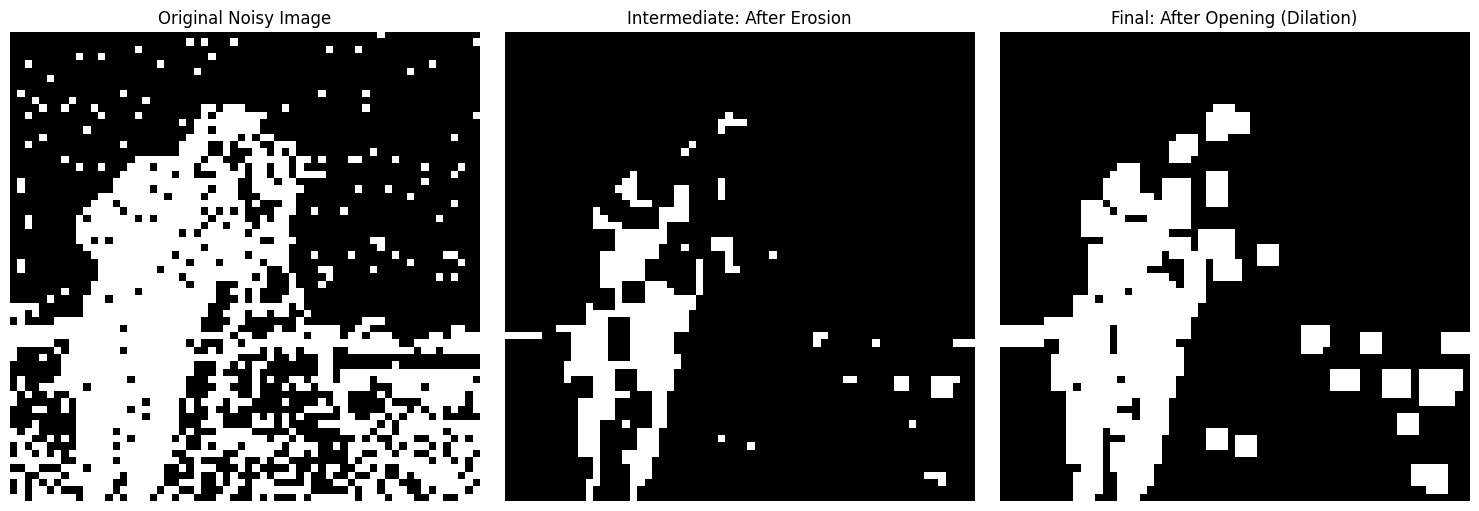

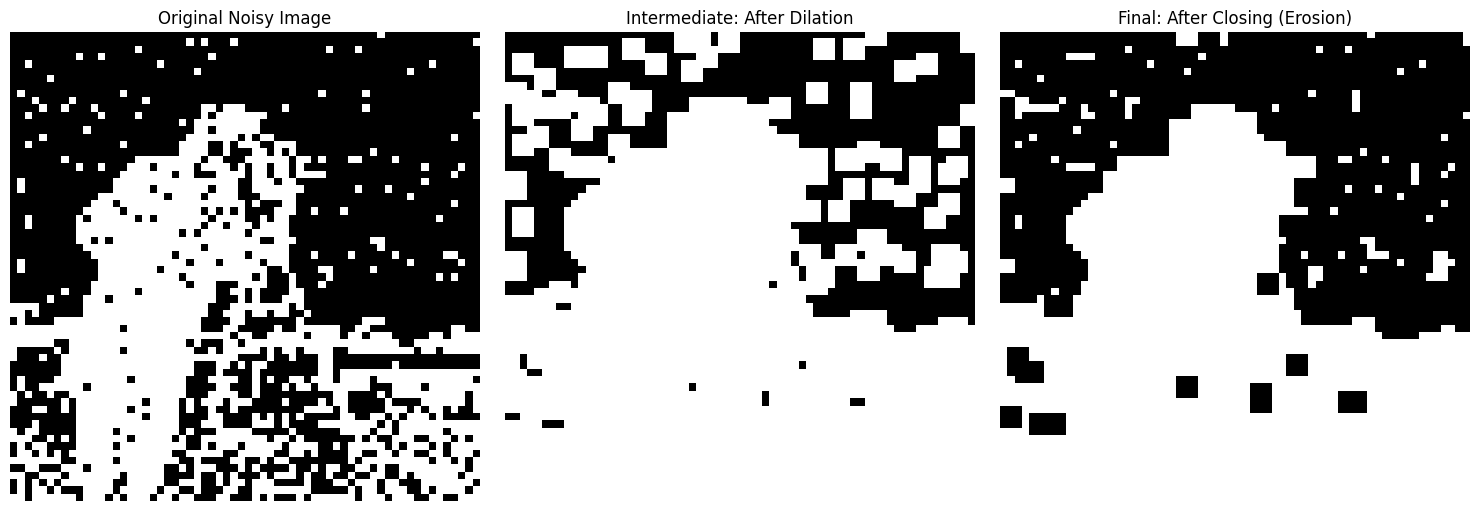

In [13]:
# 1. Apply Erosion first (removes white noise, but shrinks the actual object)
step1_eroded = erode(img_noisy, kernel)

# 2. Apply Dilation next (restores the object's original size)
opened_img = dilate(step1_eroded, kernel)

# Plotting the progression
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_noisy, cmap='gray')
axes[0].set_title('Original Noisy Image')
axes[0].axis('off')

axes[1].imshow(step1_eroded, cmap='gray')
axes[1].set_title('Intermediate: After Erosion')
axes[1].axis('off')

axes[2].imshow(opened_img, cmap='gray')
axes[2].set_title('Final: After Opening (Dilation)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# 1. Apply Dilation first (fills in black holes, but expands the actual object)
step1_dilated = dilate(img_noisy, kernel)

# 2. Apply Erosion next (restores the object's original boundary size)
closed_img = erode(step1_dilated, kernel)

# Plotting the progression
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_noisy, cmap='gray')
axes[0].set_title('Original Noisy Image')
axes[0].axis('off')

axes[1].imshow(step1_dilated, cmap='gray')
axes[1].set_title('Intermediate: After Dilation')
axes[1].axis('off')

axes[2].imshow(closed_img, cmap='gray')
axes[2].set_title('Final: After Closing (Erosion)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

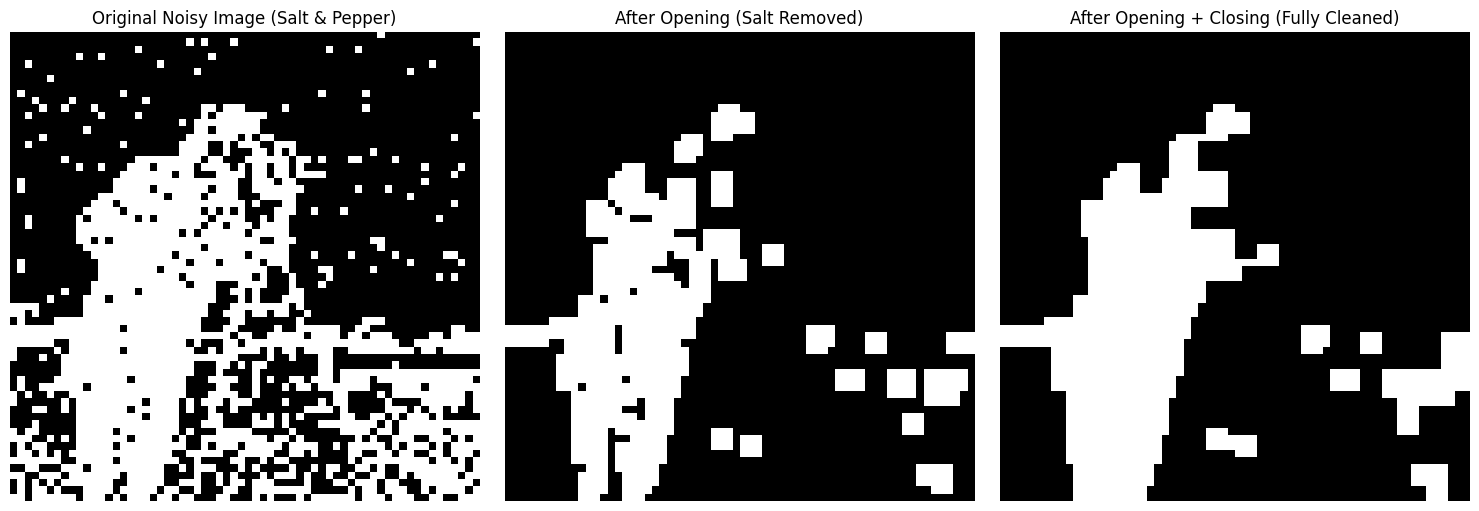

In [14]:
# 1. Apply Opening to the original noisy image to remove Salt noise
img_opened = dilate(erode(img_noisy, kernel), kernel)

# 2. Apply Closing to the OPENED image to remove the remaining Pepper noise
final_cleaned_img = erode(dilate(img_opened, kernel), kernel)

# Plotting the ultimate result
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_noisy, cmap='gray')
axes[0].set_title('Original Noisy Image (Salt & Pepper)')
axes[0].axis('off')

axes[1].imshow(img_opened, cmap='gray')
axes[1].set_title('After Opening (Salt Removed)')
axes[1].axis('off')

axes[2].imshow(final_cleaned_img, cmap='gray')
axes[2].set_title('After Opening + Closing (Fully Cleaned)')
axes[2].axis('off')

plt.tight_layout()
plt.show()